# Normalised linear stability spectra

## Packages

In [17]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True,
                 "text.usetex": True,
                 "font.family": "Computer Modern Roman"})


## Plotting font options ##
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import numpy as np

import pathlib

import sys
sys.path.append("../")

import dynplot
import Optimisation.opt as opt
import parameters
_, L, m, c = parameters.Parameters()
from twobox import TwoBox


l_width = 2.5
colorY = "blue"
colorvY = "dodgerblue"  #cornflowerblue
colorphi = "red"  #"royalblue"
colorvphi = "tomato"  #coral
colorReal = (0.7, 0, 0)
colorImag = 'blue'
colorY2 = "blue"
colorvY2 = "red"  #cornflowerblue
colorphi2 = "black"  #"royalblue"
colorvphi2 = "lightgreen"  #coral

## Load the chosen grating

In [18]:
import autolib

# runID = "PureTranslationOpt"
runID = "Fasymp20_mirror"
fname_preamble = '/Users/jlin0351/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics'
I = 5e8
final_speed = 20.
speed_range = np.array([0.,final_speed])
wavelength_range = np.array([1., 1./parameters.D1_ND([0.2,0.])])
num_points = 200

# Calculate the linear stability information for the chosen grating whose eigenvectors 
# you wish to plot alongside the dynamics
num_cores = 200
maxtime = 1440
output_opt_idx = 0

pkl_fname = fname_preamble + f'/Optimisation/Jadon\'s results/Fasymp/final_speed{int(final_speed)}/maxtime{maxtime}/{runID}_FOM_optimisation_maxtime{maxtime}'
# pkl_fname = fname_preamble + f'/Optimisation/Jadon\'s results/MdS npmin FoM/final_speed20/mirror/{runID}_FOM_optimisation_maxtime{maxtime}'
_, _, grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=output_opt_idx)
grating.npa = autolib.AutoLib('torch', device='cpu', precision='double')  # twobox.npa isn't saved during optimisation, must set manually
print(grating.params)

# Fdmp_params = [1.226     , 2.90479687, 0.31178695, 0.0071848 , 0.9995    , 2.96553672, 4.30675011]
# Fdmp_grating = TwoBox(*Fdmp_params, gaussian_width=5., substrate_depth=1., substrate_eps=-1e6,
#                       wavelength=1., angle=0., Nx=100, nG=12, Qabs=np.inf,
#                       RCWA_engine="TORCWA", torcwa_edge_sharpness=45)
# Fdmp_grating.invert_unit_cell = False

# Fdmp_grating.show_permittivity()
# Fdmp_grating.show_spectrum(0., "PDr", wavelength_range=[1,1.225], I=I, grad_method="grad")
# grating = Fdmp_grating

betas = np.linspace(0,final_speed/100, num_points)
wavelengths = np.linspace(1., 1./parameters.D1_ND([0.2,0.]), num_points)

Total function evaluations: 516418
Average function evaluations per core: 2582
[tensor(1.3420, dtype=torch.float64), tensor(0.6085, dtype=torch.float64), tensor(0.2462, dtype=torch.float64), tensor(0.3926, dtype=torch.float64), tensor(0.9713, dtype=torch.float64), tensor(3.8453, dtype=torch.float64), tensor(2.2500, dtype=torch.float64), tensor(100., dtype=torch.float64)]


### Calculate lsa quantities

In [7]:
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=True)

## Reflection spectra

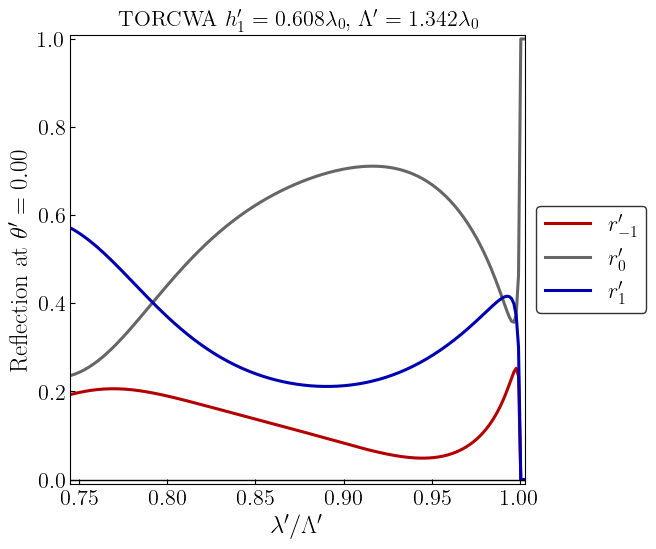

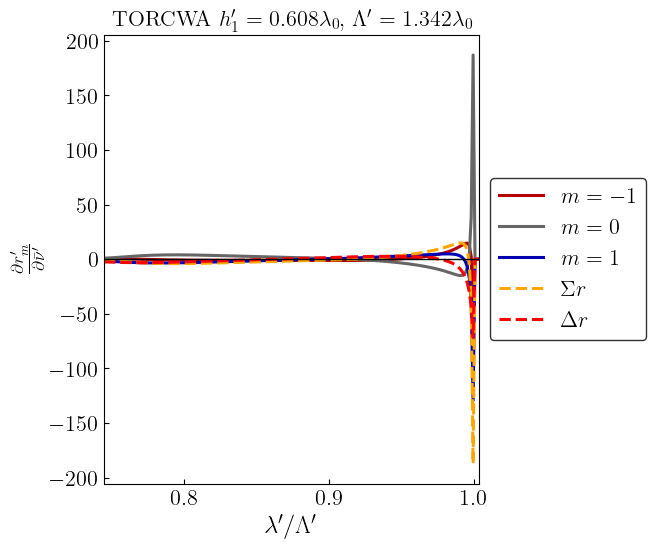

In [20]:
# r_fig, r_ax = grating.show_spectrum(0., "r", wavelength_range=wavelength_range, I=I, grad_method="grad")
# PDangle_fig, PDangle_ax = grating.show_spectrum(0., "PDr", wavelength_range=wavelength_range, I=I, grad_method="grad")
# PDwavelength_fig, PDwavelength_ax = grating.show_spectrum(0., "PDrlam", wavelength_range=wavelength_range, I=I, 
#                                                           grad_method="grad", show_freq_grad=True)
r_fig, r_ax = grating.show_spectrum(0., "r", wavelength_range=[1.,1.346], I=I, grad_method="grad")
PDwavelength_fig, PDwavelength_ax = grating.show_spectrum(0., "PDrlam", wavelength_range=[1.,1.346], I=I, 
                                                          grad_method="grad", show_freq_grad=True)
# rangle_fig, rangle_ax = grating.show_angular_efficiency(theta_max=20., num_plot_points=100)

ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}" 
r_fig.savefig(save_fname+"_r"+ftype, bbox_inches="tight")
# PDangle_fig.savefig(save_fname+"_PDr"+ftype, bbox_inches="tight")
PDwavelength_fig.savefig(save_fname+"_PDrwavelength"+ftype, bbox_inches="tight")
# rangle_fig.savefig(save_fname+"_rangle"+ftype, bbox_inches="tight")

## Eigenvalues and eigenvectors

In [ ]:
# Plot eigenvectors separately
log_axis = False
eigvec_fig, axs = plt.subplots(3,2, figsize=(10,9))

axs_flat = axs.flatten()
axs_flat[0].plot(betas, real_eigvals, color=colorReal, linewidth=l_width)
axs_flat[1].plot(betas, imag_eigvals, color=colorImag, linewidth=l_width)
axs_flat[0].set_yscale('linear')
axs_flat[1].set_yscale('linear')
axs_flat[0].set(xlim=(betas[0],betas[-1]))
axs_flat[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(axs_flat[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(axs_flat[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)

axs_flat = axs_flat[2:]
# axs_flat[1], axs_flat[2] = axs_flat[2], axs_flat[1]  # switch so that degenerate eigvec magnitudes are shown in columns
for eigvec_idx, ax in enumerate(axs_flat):
    ax.plot(betas, eigvec_moduli[:,0,eigvec_idx], label=r"$y$", color=colorY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,1,eigvec_idx], label=r"$\phi$", color=colorphi2, linewidth=l_width, linestyle="--")
    ax.plot(betas, eigvec_moduli[:,2,eigvec_idx], label=r"$v_y$", color=colorvY2, linewidth=l_width)
    ax.plot(betas, eigvec_moduli[:,3,eigvec_idx], label=r"$\dot{\phi}$", color=colorvphi2, linewidth=l_width, linestyle="--")

    if log_axis:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(1e-9,1e1))
        ax.set_yscale('log')
    else:
        ax.set(xlim=(betas[0],betas[-1]), ylim=(-0.05,1.05))
    ax = dynplot.show_standard_axes(ax, None, xlabel=None, ylabel=rf"$|v_{{{eigvec_idx},i}}|/||\mathbf{{v}}_{{{eigvec_idx}}}||$", show_zero_line=False)
    

eigvec_fig.supxlabel(r"$\beta$")
handles, labels = ax.get_legend_handles_labels()
leg = eigvec_fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.1,0.5))

# print(imag_eigvals[0:10,:])
# print(real_eigvals[0:10,:])

ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_eigen" + ftype
eigvec_fig.savefig(save_fname, bbox_inches="tight")

## Jacobian terms spectra

### All terms

Grouped by acceleration or angular acceleration

Can choose to calculate the Jacobian terms using Qpr derivatives or directly from the diffraction derivatives.

In [15]:
# # # Jacobians terms directly from Qpr derivatives
# kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
# muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

# Jacobian terms from semi-analytic expressions
deriv_scaler = 10.

input_wavelength = grating.wavelength
gnp = grating.npa

kyy = gnp.zeros(num_points)
kyphi = gnp.zeros(num_points)
kphiy = gnp.zeros(num_points)
kphiphi = gnp.zeros(num_points)
muyy = gnp.zeros(num_points)
muyphi = gnp.zeros(num_points)
muphiy = gnp.zeros(num_points)
muphiphi = gnp.zeros(num_points)

wbar = grating.gaussian_width/L
w0_1 = 1 - gnp.exp(-1/(2*wbar**2))
w12_0 = wbar/2 * gnp.sqrt(gnp.array(np.pi/2)) * gnp.erf(1/(gnp.sqrt(gnp.array(2))*wbar))
w0_0 = w12_0 - 1/2*gnp.exp(-1/(2*wbar**2))
w18_0 = wbar**2/4 * w0_1
w124_0 = wbar**2/4 * w0_0
for i, lam in enumerate(wavelengths):
    grating.wavelength = lam
    sm = gnp.array([-lam/grating.grating_pitch, 0., lam/grating.grating_pitch])
    cm = gnp.sqrt(1 - sm**2)
    D = 1./lam
    gamma = (1 + lam**2)/(2*lam)
    rm, tm = grating.eff()
    PDrPDangles = deriv_scaler*gnp.array([grating.PDrNeg1(0.), grating.PDr0(0.), grating.PDr1(0.)])
    PDtPDangles = deriv_scaler*gnp.array([grating.PDtNeg1(0.), grating.PDt0(0.), grating.PDt1(0.)])
    PDrPDwavelengths = deriv_scaler*gnp.array([grating.PDrNeg1PDwavelength(lam), grating.PDr0PDwavelength(lam), grating.PDr1PDwavelength(lam)])
    PDtPDwavelengths = deriv_scaler*gnp.array([grating.PDtNeg1PDwavelength(lam), grating.PDt0PDwavelength(lam), grating.PDt1PDwavelength(lam)])

    kyy[i] = 2*D**2 * gnp.sum((rm + tm)*sm) * w0_1
    kphiy[i] = 2*D**2 * (1 + gnp.sum((rm - tm)*cm)) * w0_0
    kyphi[i] = kphiy[i]*w12_0/w0_0 + 2*D**2 * gnp.sum((PDrPDangles + PDtPDangles)*sm) * w12_0
    kphiphi[i] = 2*D**2 * gnp.sum((PDrPDangles - PDtPDangles)*cm - (rm - tm)*sm/cm) * w18_0
    muyy[i] = (D+1)/(D*(gamma+1)) * (kyphi[i] - kphiy[i]*w12_0/w0_0)
    muphiy[i] = (D+1)/(D*(gamma+1)) * kphiphi[i]
    muyphi[i] = -kyy[i]*w18_0/w0_1 + 2*D**3 * gnp.sum((PDrPDwavelengths + PDtPDwavelengths)*sm) * w18_0
    muphiphi[i] = -kphiy[i]*w124_0/w0_0 - 2*D**2 * (1 - gnp.sum((PDrPDwavelengths - PDtPDwavelengths)*D*cm - (rm - tm)/cm)) * w124_0
    # muyphi[i] = 2*D**2 * gnp.sum((PDrPDwavelengths + PDtPDwavelengths)*D*sm - (rm + tm)*sm) * w18_0
    # muphiphi[i] = - 2*D**2 * (2 - gnp.sum((PDrPDwavelengths - PDtPDwavelengths)*D*cm - (rm - tm)*(cm + 1/cm))) * w124_0

kyy = grating.to_numpy(kyy)
kyphi = grating.to_numpy(kyphi)
kphiy = grating.to_numpy(kphiy)
kphiphi = grating.to_numpy(kphiphi)
muyy = grating.to_numpy(muyy)
muyphi = grating.to_numpy(muyphi)
muphiy = grating.to_numpy(muphiy)
muphiphi = grating.to_numpy(muphiphi)

grating.wavelength = input_wavelength  # reset wavelength to original value

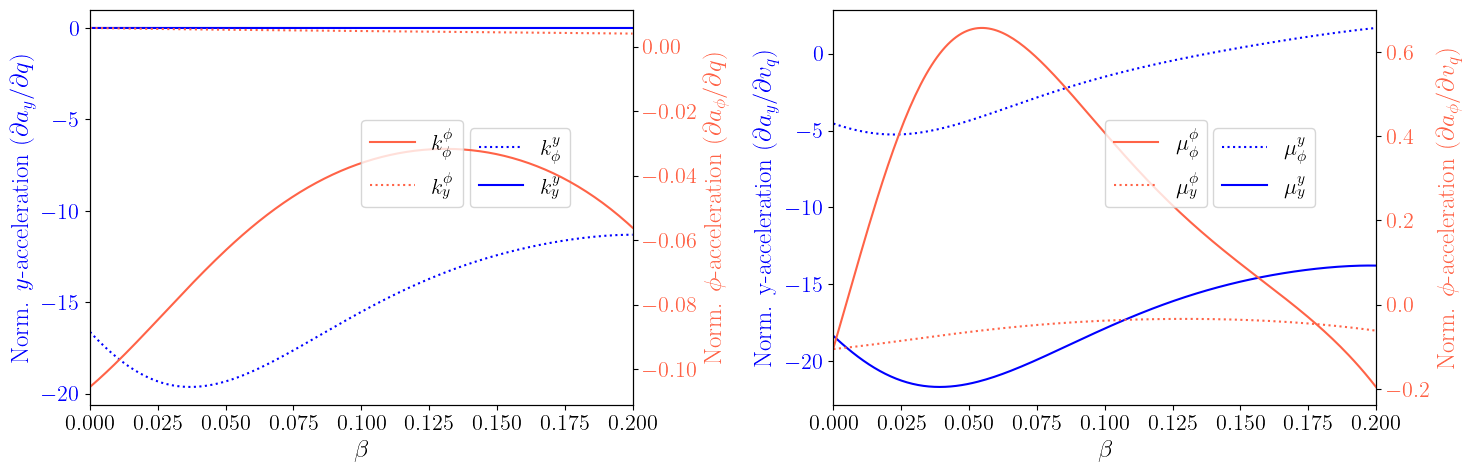

In [16]:
################
# Restoring terms
stiff_fig,(ax, ax2) = plt.subplots(1,2,figsize=(15,5))


ax.plot(betas, kyphi,  label=r"$k^y_\phi$",color=colorY,linestyle="dotted")
ax.plot(betas, kyy,    label=r"$k^y_y$",color=colorY)

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Norm. $y$-acceleration ($\partial a_y/\partial q$)",color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)


# ax.hlines(0,0,5,"k","dashed",alpha=0.2)
t = ax.get_ylim()
# ax.axhspan(0,t[1],color='black',alpha=0.2)

ax1 = ax.twinx()
ax1.plot(betas, kphiy,  label=r"$k^\phi_y$",color=colorvphi,linestyle="dotted")
ax1.plot(betas,kphiphi,label=r"$k^\phi_\phi$",color=colorvphi)

ax1.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)",color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])

handles, labels = ax.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax1.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

########################
ax2.plot(betas,muyphi, label=r"$\mu^y_\phi$", color=colorY,linestyle="dotted")
ax2.plot(betas,muyy, label=r"$\mu^y_y$",color=colorY)
ax2
ax2.set_xlabel(r"$\beta$")
ax2.set_ylabel(r"Norm. y-acceleration ($\partial a_y/\partial v_q$)", color=colorY)
ax2.tick_params(axis='y', labelcolor=colorY)

t=ax2.get_ylim()
ax2b=ax2.twinx()

ax2b.plot(betas,muphiy, label=r"$\mu^\phi_y$",color=colorvphi,linestyle="dotted")
ax2b.plot(betas,muphiphi, label=r"$\mu^\phi_\phi$", color=colorvphi)


ax2b.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial v_q$)",color=colorvphi)
ax2b.tick_params(axis='y',labelcolor=colorvphi)

# # Does not correspond to 1.28%
# ax.vlines(1.4507253626813408,t[0],0,color='k',linestyle='dashed',alpha=0.2)
# ax.hlines(0,0,1.4507253626813408,color='k',linestyle='dashed',alpha=0.2)

ax2.set_ylim(t)
ax2.set_xlim(betas[0],betas[-1])

# ax.set_xticks([0,1,1.45,2,3,4,5])
 
handles, labels = ax2.get_legend_handles_labels()
handles1, labels1 = ax2b.get_legend_handles_labels()
order = [0,1]
order1=[1,0]
ax2.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=(0.5+0.2,0.5))
ax2b.legend([handles1[idx] for idx in order1],[labels1[idx] for idx in order1],loc=(0.5,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_jacobian_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

### Only restoring force/torque

In [ ]:
stiff_fig, ax = plt.subplots(1,figsize=(6,4))

kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

ax.plot(betas, kyy,    label=r"$\bar{k}^y_y$",color=colorY)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"Norm. $y$-acceleration ($\partial a_y/\partial q$)",color=colorY)
ax.tick_params(axis='y',labelcolor=colorY)

t = ax.get_ylim()
ax1 = ax.twinx()
ax1.plot(betas,kphiphi,label=r"$\bar{k}^\phi_\phi$",color=colorvphi)
ax1.set_ylabel(r"Norm. $\phi$-acceleration ($\partial a_\phi/\partial q$)",color=colorvphi)
ax1.tick_params(axis='y',labelcolor=colorvphi)

vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
s1 = 1./Dopplers/grating.grating_pitch
c1 = np.sqrt(1 - s1**2)
w = grating.gaussian_width/L
w0_1 = 1 - np.exp(-1/(2*w*2))
w18_0 = (w/2)**2 * w0_1
ax1.plot(betas, -kyy/c1*w18_0/w0_1, 
         label=r"$-\frac{\bar{k}^y_y}{\cos\delta_1'}\frac{w^{\rightarrow 1/8}_{0\leftarrow}}{w^{\rightarrow 0}_{1\leftarrow}}$", 
         color="black")


ax.set_ylim(t)
ax.set_xlim(betas[0],betas[-1])

stiff_fig.legend(loc='center left', bbox_to_anchor=(1.0,0.5))

stiff_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_restoring_coefficients" + ftype
# stiff_fig.savefig(save_fname, bbox_inches="tight")

grating.show_spectrum(0., "PDr", wavelength_range=[1,1.225], I=I, grad_method="grad")

## Routh-Hurwitz stability

In [ ]:
# Cannot normalise Jacobian terms when calculating Routh-Hurwitz coefficients or eigen
restoring_coeffs, damping_coeffs, real_eigvals, imag_eigvals, eigvec_moduli = dynplot.generate_lsa_spectrum(grating, speed_range, I, num_points, normalise=False)
kyy, kyphi, kphiy, kphiphi = restoring_coeffs.T
muyy, muyphi, muphiy, muphiphi = damping_coeffs.T

betas = np.linspace(0,final_speed/100, num_points)

In [ ]:
muyy_scaled = muyy
kyphi_scaled = kyphi

a1 = -muyy_scaled - muphiphi
a2 = muyy_scaled*muphiphi - muyphi*muphiy - (kyy + kphiphi)
a3 = kyy*muphiphi + kphiphi*muyy_scaled - (kyphi_scaled*muphiy + kphiy*muyphi)
a4 = kyy*kphiphi - kyphi_scaled*kphiy

condition1 = a1
condition2 = a1*a2 - a3
condition3 = a3*condition2 - a1**2*a4
condition4 = a4

RH_fig, RH_ax = plt.subplots(1,figsize=(6,5))
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition1, linewidth=2.5, color="red", linestyle="-", label=r"Negative damping coeff")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition2, linewidth=2.5, color="magenta", linestyle="--", label=r"Mixed 1")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition3, linewidth=2.5, color="cyan", linestyle="--", label=r"Mixed 2")
RH_ax = dynplot.plot_array_on_same_axes(RH_ax, betas, condition4, linewidth=2.5, color="blue", linestyle="-", label=r"Restoring $\textgreater$ Coupling")
RH_ax = dynplot.show_standard_axes(RH_ax, betas, xlabel=r"$\beta$", ylabel=r"Routh-Hurwitz coefficients (arb. units)", show_zero_line=True, ax_width=2.5)
RH_fig.legend(loc='upper right')
RH_ax.set_yscale('log')

RH_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_Routh_Hurwitz" + ftype
RH_fig.savefig(save_fname, bbox_inches="tight")

#### Eigenvalues from scaled Jacobian terms

In [ ]:
scaled_eigval_fig, scaled_eigval_ax = plt.subplots(1,2,figsize=(10,4.5))
real_eigvals = []
imag_eigvals = []
for i in range(num_points):
    Jac = grating.npa.array([[0, 0, 1, 0],[0, 0, 0, 1], 
                             [kyy[i], kyphi_scaled[i], muyy_scaled[i], muyphi[i]], 
                             [kphiy[i], kphiphi[i], muphiy[i], muphiphi[i]]])
    eigvals = grating.npa.eigvals(Jac)
    real_eigvals.append(grating.npa.real(eigvals))
    imag_eigvals.append(grating.npa.imag(eigvals))
scaled_eigval_ax[0].plot(betas, grating.to_numpy(real_eigvals), color=colorReal, linewidth=l_width)
scaled_eigval_ax[1].plot(betas, grating.to_numpy(imag_eigvals), color=colorImag, linewidth=l_width)
scaled_eigval_ax[0].set_yscale('linear')
scaled_eigval_ax[1].set_yscale('linear')
scaled_eigval_ax[0].set(xlim=(betas[0],betas[-1]))
scaled_eigval_ax[1].set(xlim=(betas[0],betas[-1]))
dynplot.show_standard_axes(scaled_eigval_ax[0], None, xlabel=None, ylabel=r"$\Re(\xi)$ (s$^{-1}$)", show_zero_line=True)
dynplot.show_standard_axes(scaled_eigval_ax[1], None, xlabel=None, ylabel=r"$\Im(\xi)$ (s$^{-1}$)", show_zero_line=True)
scaled_eigval_fig.supxlabel(r"$\beta$")
# scaled_eigval_ax[0].set_yscale('symlog', linthresh=1e-5)
# scaled_eigval_ax[0].set_ylim(-3e-4,0.)

scaled_eigval_fig.tight_layout()
ftype = ".pdf"
save_fname = fname_preamble + f"/Dynamics/{runID}_scaled_Jacobian_eigenvalues" + ftype
# scaled_eigval_fig.savefig(save_fname, bbox_inches="tight")

## Doppler factor

In [ ]:
import dynplot

betas = np.linspace(0,final_speed/100, num_points)
vels = [[b,0] for b in betas]
Dopplers = np.array(parameters.D1_ND(vels))
gammas = np.array(parameters.gamma_ND(vels))
Dsq = Dopplers**2
D_plus_1 = (Dopplers+1)/(Dopplers*(gammas+1))
fig, ax = plt.subplots(1, figsize=(6,5))
ax = dynplot.plot_array_on_same_axes(ax, betas, Dopplers, linewidth=2.5, color="red", linestyle="--", label=r"$D$")
ax = dynplot.plot_array_on_same_axes(ax, betas, Dsq, linewidth=2.5, color="blue", linestyle="-", label=r"$D^2$")
ax = dynplot.plot_array_on_same_axes(ax, betas, D_plus_1, linewidth=2.5, color="green", linestyle="-.", label=r"$(D+1)/[D(\gamma+1)]$")
ax = dynplot.show_standard_axes(ax, betas, xlabel=r"$\beta$", ylabel=r"Doppler factor", show_zero_line=False, ax_width=2.5)
fig.legend(loc='upper right')